In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'sans-serif',
    'font.size': 20,
    'axes.labelsize': 20,
    'axes.titlesize': 14,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
})

In [ ]:
# ── parametros ──────────────────────────────────────────
XLSX_PATH = '/Users/arielhertz/Desktop/Claw-like Tweezer/python scripts - yolo&plots/Valores.xlsx'
DPI = 2000            # resolucao do pdf (300 publicacao, 600 poster)
SAVE = False          # True salva pdf, False so mostra

In [20]:
# ── leitura e limpeza ───────────────────────────────────
df = pd.read_excel(XLSX_PATH, header=None)

concentrations = [int(float(c)) for c in df.iloc[0, 1:].tolist()]

data_rows = [i for i in range(1, len(df))
             if pd.notna(df.iloc[i, 0]) and str(df.iloc[i, 0]).strip() != '']

valid = {c: [] for c in concentrations}
for row in data_rows:
    for col, conc in enumerate(concentrations, start=1):
        cell = str(df.iloc[row, col])
        if '*' not in cell and ',' not in cell:
            valid[conc].append(float(cell))

concs  = np.array(concentrations)
means  = np.array([np.mean(valid[c]) for c in concs])
sems   = np.array([np.std(valid[c], ddof=1) / np.sqrt(len(valid[c])) for c in concs])

print(f'Concentracoes: {concs}')
print(f'N validos:     {[len(valid[c]) for c in concs]}')
print(f'Medias (Abs):  {np.round(means, 1)}')
print(f'SEM:           {np.round(sems, 1)}')

Concentracoes: [ 0 30 33 36 37 39 40 42 43 45 46 48]
N validos:     [11, 8, 9, 10, 11, 11, 11, 10, 11, 10, 10, 11]
Medias (Abs):  [98.4 45.5 32.5 24.4 22.6 27.9 28.8 26.5 25.  32.1 35.8 33.9]
SEM:           [1.  6.8 5.8 4.8 5.  3.8 4.7 2.5 2.8 3.7 3.3 2.8]


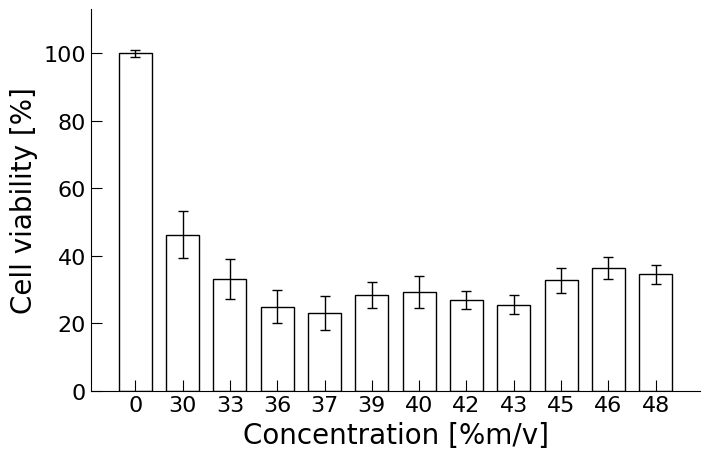

In [21]:
# ── grafico 1: viabilidade (%) ──────────────────────────
ctrl = means[0]
pct_means = means / ctrl * 100
pct_sems  = sems  / ctrl * 100

x = np.arange(len(concs))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.bar(x, pct_means, width=0.7, color='white', edgecolor='black', linewidth=1.0)
ax.errorbar(x, pct_means, yerr=pct_sems, fmt='none',
            ecolor='black', elinewidth=1.0, capsize=3.5, capthick=1.0)

ax.set_xticks(x)
ax.set_xticklabels([str(c) for c in concs])
ax.set_xlabel('Concentration [%m/v]')
ax.set_ylabel('Cell viability [%]')
ax.set_ylim(0, max(pct_means + pct_sems) * 1.12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
if SAVE:
    plt.savefig("cell_viability_rel.pdf",format='pdf', dpi=DPI, bbox_inches='tight')
plt.show()

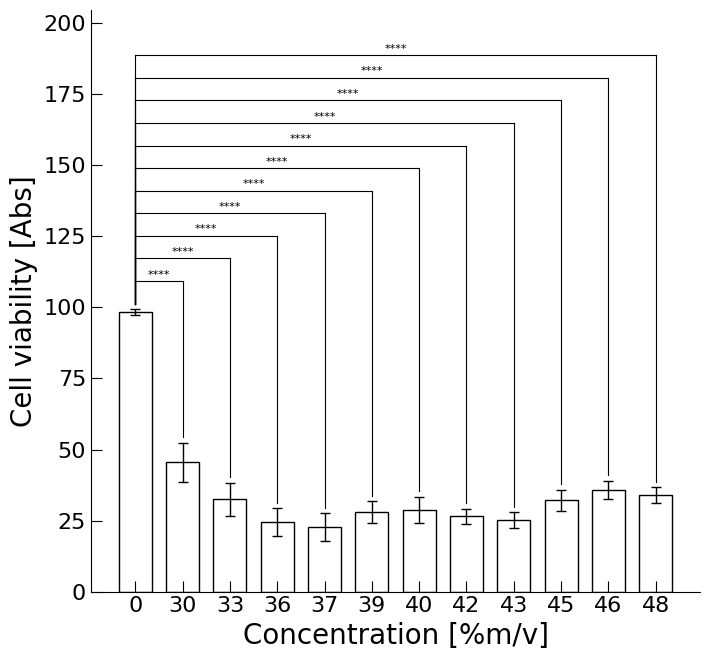

In [22]:
# ── grafico 2: absorbancia + significancia ──────────────
fig, ax = plt.subplots(figsize=(7.5, 7))
ax.bar(x, means, width=0.7, color='white', edgecolor='black', linewidth=1.0)
ax.errorbar(x, means, yerr=sems, fmt='none',
            ecolor='black', elinewidth=1.0, capsize=3.5, capthick=1.0)

ax.set_xticks(x)
ax.set_xticklabels([str(c) for c in concs])
ax.set_xlabel('Concentration [%m/v]')
ax.set_ylabel('Cell viability [Abs]')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# brackets de significancia (**** vs controle)
bar_tops = means + sems
gap      = max(bar_tops) * 0.08
y_start  = max(bar_tops) * 1.10

for i in range(1, len(concs)):
    y = y_start + (i - 1) * gap
    ax.plot([0, 0], [bar_tops[0] + 2, y], lw=0.8, color='black', clip_on=False)
    ax.plot([0, x[i]], [y, y], lw=0.8, color='black', clip_on=False)
    ax.plot([x[i], x[i]], [bar_tops[i] + 2, y], lw=0.8, color='black', clip_on=False)
    ax.text((0 + x[i]) / 2, y + 0.5, '****',
            ha='center', va='bottom', fontsize=8)

top = y_start + len(concs) * gap
ax.set_ylim(0, top)

plt.tight_layout()
if SAVE:
    plt.savefig("cell_viability_abs.pdf",format='pdf', dpi=DPI, bbox_inches='tight')
plt.show()